In [5]:
import pandas as pd
df_stat_h1 = pd.read_csv("https://raw.githubusercontent.com/lunettenoire/Project/refs/heads/main/df_h1.csv")
df_stat_h1 = df_stat_h1.dropna(subset=["healthy_life_expectancy_at_birth"])

Pour pouvoir faire une comparaison temporelle, il faut normaliser (mettre toutes les valeurs entre 0 et 1)

**Pourquoi normaliser les données ?**\
En statistiques, il est impossible de comparer ou d’additionner directement des indicateurs exprimés dans des unités différentes, comme le bonheur (noté de 0 à 10), l’espérance de vie (en années) ou le PIB (en valeur logarithmique). Sans ajustement, la donnée ayant la plus grande amplitude numérique (par exemple l'espérance de vie) écraserait mathématiquement les autres, rendant leur influence quasi nulle sur le résultat final.\ La normalisation consiste à transformer ces valeurs pour les ramener à une échelle commune, généralement comprise entre 0 et 1. Cette étape est indispensable pour mettre tous les critères sur un pied d'égalité : elle permet de créer des indices composites équilibrés où chaque dimension contribue de manière équitable au score global.

In [11]:
cols_to_norm = df_stat_h1[["life_ladder", "log_gdp_per_capita", "healthy_life_expectancy_at_birth"]] # les colonnes à normaliser
for col in cols_to_norm:
    df_stat_h1[col + '_norm'] = (df_stat_h1[col] - df_stat_h1[col].min()) / (df_stat_h1[col].max() - df_stat_h1[col].min())
# les colonnes X_norm sont ajoutées à la fin du DF

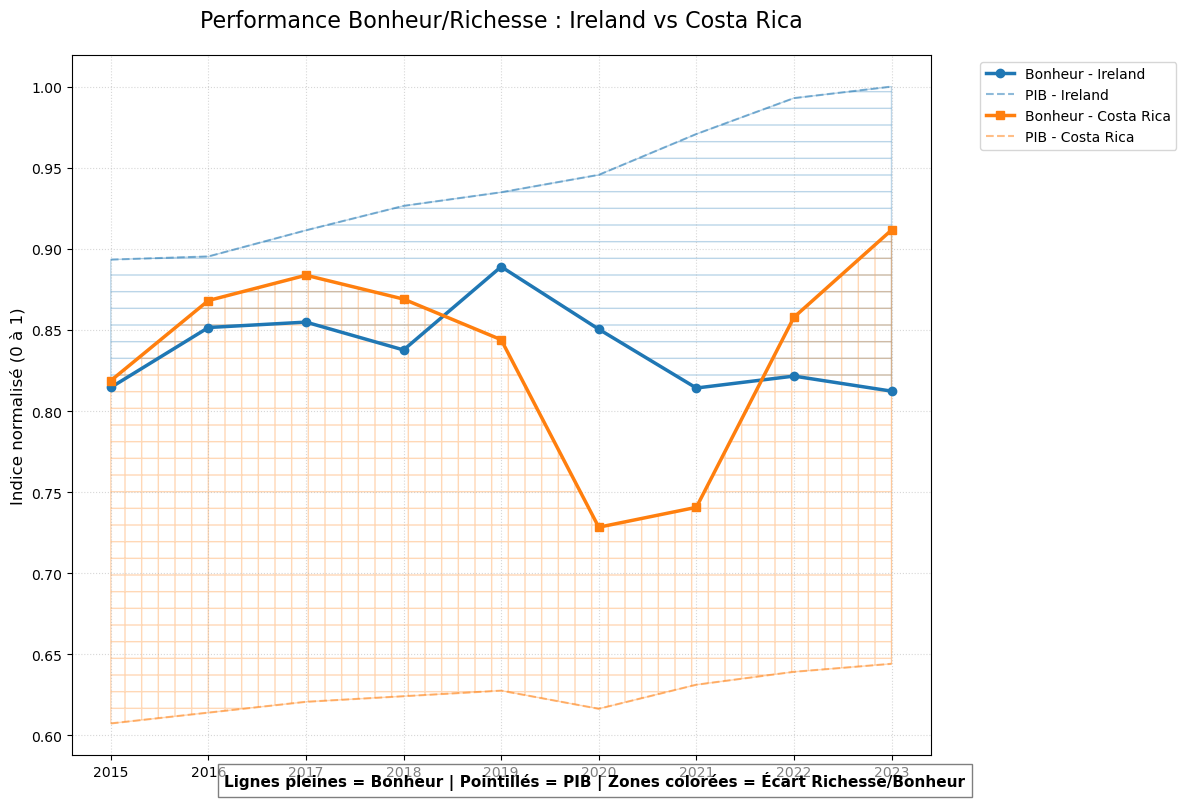

In [29]:
import matplotlib.pyplot as plt

def trajectoire_avec_remplissage(pays1, pays2, df):
    # 1. Préparation des données
    data1 = df[df['country_name'] == pays1].sort_values('year')
    data2 = df[df['country_name'] == pays2].sort_values('year')
    
    plt.figure(figsize=(12, 8))
    
    # --- PAYS 1 : IRELAND (Bleu) ---
    # On trace les lignes
    plt.plot(data1['year'], data1['life_ladder_norm'], 
             label=f'Bonheur - {pays1}', color='tab:blue', marker='o', linewidth=2.5)
    plt.plot(data1['year'], data1['log_gdp_per_capita_norm'], 
             label=f'PIB - {pays1}', color='tab:blue', linestyle='--', alpha=0.5)
    
    plt.fill_between(data1['year'], 
                 data1['life_ladder_norm'], 
                 data1['log_gdp_per_capita_norm'], 
                 facecolor="none",       # On ne met pas de couleur de fond (ou très légère)
                 edgecolor="tab:blue",   # La couleur des traits du motif
                 hatch='-',              # Le motif (ici des lignes horizontales)
                 alpha=0.3)              # La transparence du motif

    # --- PAYS 2 : COSTA RICA (Orange) ---
    # On trace les lignes
    plt.plot(data2['year'], data2['life_ladder_norm'], 
             label=f'Bonheur - {pays2}', color='tab:orange', marker='s', linewidth=2.5)
    plt.plot(data2['year'], data2['log_gdp_per_capita_norm'], 
             label=f'PIB - {pays2}', color='tab:orange', linestyle='--', alpha=0.5)
    
    # ON REMPLIT L'ESPACE POUR LE COSTA RICA (Orange avec hachures croisées par exemple)
    plt.fill_between(data2['year'], 
                 data2['life_ladder_norm'], 
                 data2['log_gdp_per_capita_norm'], 
                 facecolor="none", 
                 edgecolor="tab:orange", 
                 hatch='+',              # Le signe '+' donne un effet de quadrillage
                 alpha=0.3)

    # --- MISE EN FORME ---
    plt.title(f"Performance Bonheur/Richesse : {pays1} vs {pays2}", fontsize=16, pad=20)
    plt.ylabel("Indice normalisé (0 à 1)", fontsize=12)
       
    # Légende en dehors
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    
    plt.grid(True, linestyle=':', alpha=0.5)
    
    # Légende explicative pour le code visuel
    plt.figtext(0.5, 0.01, "Lignes pleines = Bonheur | Pointillés = PIB | Zones colorées = Écart Richesse/Bonheur", 
                ha="center", fontsize=11, fontweight='bold', bbox={"facecolor":"white", "alpha":0.5, "pad":5})

    plt.tight_layout()
    plt.show()

# Appel de la fonction
trajectoire_avec_remplissage("Ireland", "Costa Rica", df_stat_h1)